In [ ]:
!pip uninstall mediapipe -y
!pip install mediapipe==0.10.14

Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (35.7 MB)


In [ ]:
import cv2
import mediapipe as mp
import math
from google.colab.patches import cv2_imshow
from google.colab import files

In [ ]:
# Initialize MediaPipe Hands
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)
mp_draw = mp.solutions.drawing_utils

In [ ]:
print("Please upload an image of a hand...")
uploaded = files.upload()

Please upload an image of a hand...


Saving download.jpg to download.jpg


In [ ]:
if uploaded:
    image_name = list(uploaded.keys())[0]

    img = cv2.imread(image_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

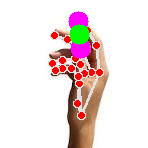

In [ ]:
results = hands.process(img_rgb)
if results.multi_hand_landmarks:

  for hand_landmarks in results.multi_hand_landmarks:
    mp_draw.draw_landmarks(img, hand_landmarks, mp_hands.HAND_CONNECTIONS)
    index_tip = hand_landmarks.landmark[8]
    thumb_tip = hand_landmarks.landmark[4]

    h, w, c = img.shape
    ix, iy = int(index_tip.x * w), int(index_tip.y * h)
    tx, ty = int(thumb_tip.x * w), int(thumb_tip.y * h)

    cv2.circle(img, (ix, iy), 10, (255, 0, 255), cv2.FILLED)
    cv2.circle(img, (tx, ty), 10, (255, 0, 255), cv2.FILLED)
    cv2.line(img, (ix, iy), (tx, ty), (255, 0, 255), 3)
    distance = math.hypot(tx - ix, ty - iy)
    if distance < 40:
      gesture = "Pinch (Click!)"
      cv2.circle(img, ((ix + tx) // 2, (iy + ty) // 2), 10, (0, 255, 0), cv2.FILLED)
    else:
      gesture = "Open/Idle"
      cv2.putText(img, f'Gesture: {gesture}', (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)
      print(f"Detected Gesture: {gesture}")

  cv2_imshow(img)
  cv2.waitKey(0)
  cv2.destroyAllWindows()
else:
  print("No hand detected in the image.")